In [16]:
from pathlib import Path 

import pandas as pd
from matplotlib import pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
output_figure_folder = Path('../reports/figures')

# Load Data

In [3]:
file_prefix = "Civilian_Complaint_Review_Board__"
data_folder = Path('../data')
data_files = sorted(data_folder.rglob(f"{file_prefix}*"))

In [6]:
assert data_folder.exists()
assert len(data_files) != 0 
data_files

[PosixPath('../data/Civilian_Complaint_Review_Board__Allegations_Against_Police_Officers_20251208.csv'),
 PosixPath('../data/Civilian_Complaint_Review_Board__Complaints_Against_Police_Officers_20251208.csv'),
 PosixPath('../data/Civilian_Complaint_Review_Board__Penalties_20251208.csv'),
 PosixPath('../data/Civilian_Complaint_Review_Board__Police_Officers_20251208.csv')]

In [7]:
data_df = {}
for data_file in data_files:
    file_key = '-'.join(data_file.stem.removeprefix(file_prefix).split('_')[:-1])
    data_df[file_key] = pd.read_csv(data_file)

# Plot

## Total CCRB Received

In [ ]:
df_complaints = data_df["Complaints-Against-Police-Officers"]
df_complaints['CCRB Received Date'] = pd.to_datetime(
    df_complaints['CCRB Received Date'], 
    format="%m/%d/%Y %I:%M:%S %p", 
    errors='coerce'
)


In [13]:
df_complaints['year'] = df_complaints['CCRB Received Date'].dt.year
counts = df_complaints.groupby('year').size()

### By Year

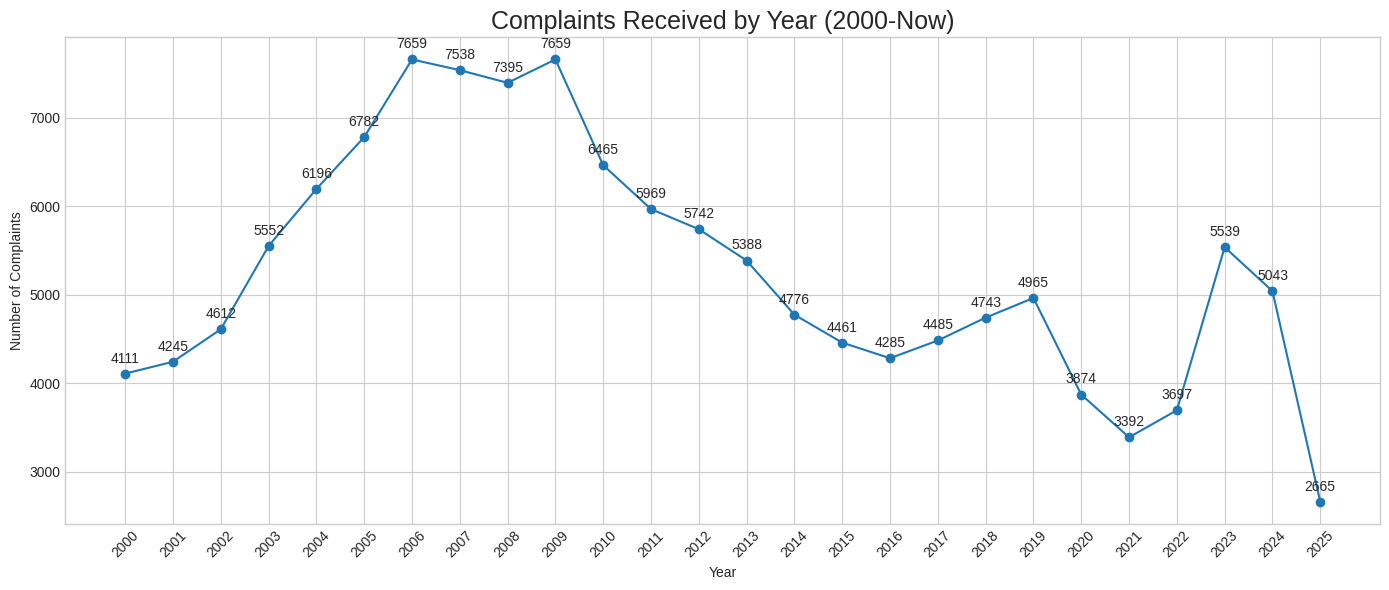

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(counts.index, counts.values, marker='o')

for x, y in zip(counts.index, counts.values):
    ax.annotate(str(y), (x, y), textcoords="offset points", xytext=(0, 8), ha='center')

ax.set_title("Complaints Received by Year (2000-Now)", fontsize=18)
ax.set_xlabel("Year")
ax.set_ylabel("Number of Complaints")
ax.set_xticks(counts.index)
ax.set_xticklabels(counts.index, rotation=45)
fig.tight_layout()

fig.savefig(output_figure_folder / "1_Complaints_by_Year")

### By Quarter

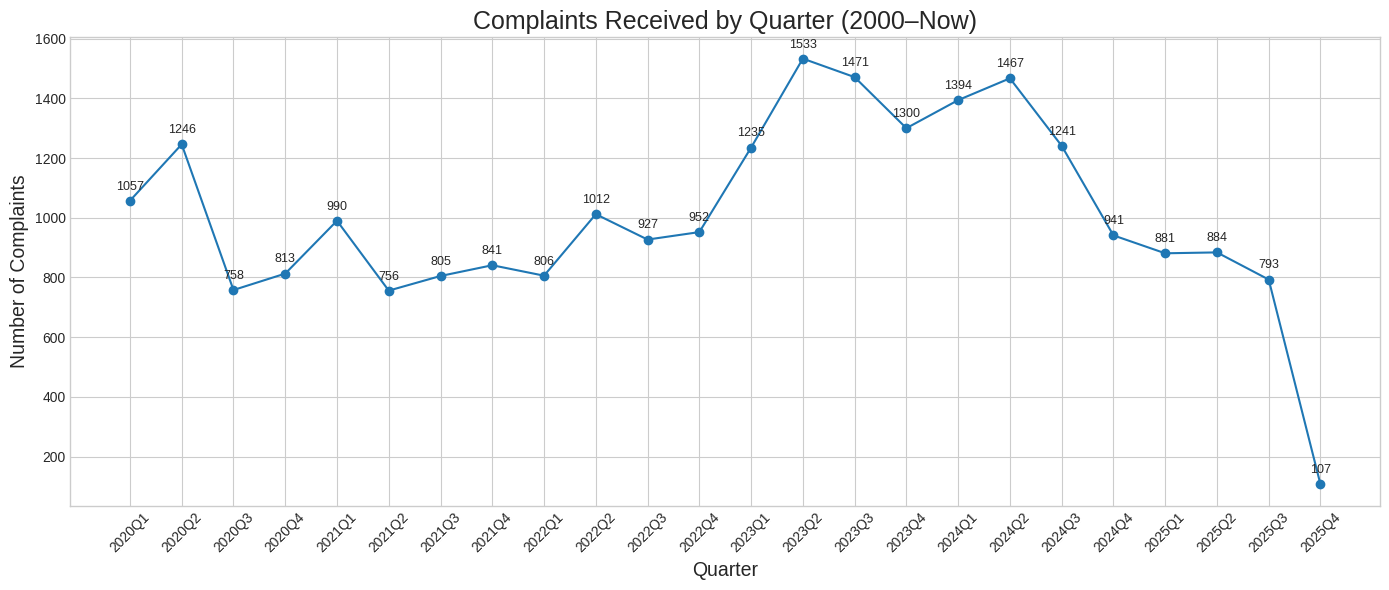

In [ ]:
# Create quarter column
df_complaints['quarter'] = df_complaints['CCRB Received Date'].dt.to_period('Q')

# Count complaints per quarter
counts_q = df_complaints.groupby('quarter').size()

# Filter the quarters after 2020 
counts_q = counts_q[counts_q.index.year >= 2020]

# Convert PeriodIndex to string for plotting
quarters = counts_q.index.astype(str)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(quarters, counts_q.values, marker='o')

# Annotate each point with the count
for x, y in zip(quarters, counts_q.values):
    ax.annotate(str(y), (x, y), textcoords="offset points",
                xytext=(0, 8), ha='center', fontsize=9)

# Title and labels
ax.set_title("Complaints Received by Quarter (2000–Now)", fontsize=18)
ax.set_xlabel("Quarter", fontsize=14)
ax.set_ylabel("Number of Complaints", fontsize=14)

# Fix xticks
ax.set_xticks(quarters)
ax.set_xticklabels(quarters, rotation=45, fontsize=10)

fig.tight_layout()
fig.savefig(output_figure_folder / "2_Complaints_by_Quarter.png")

### By Half-Year

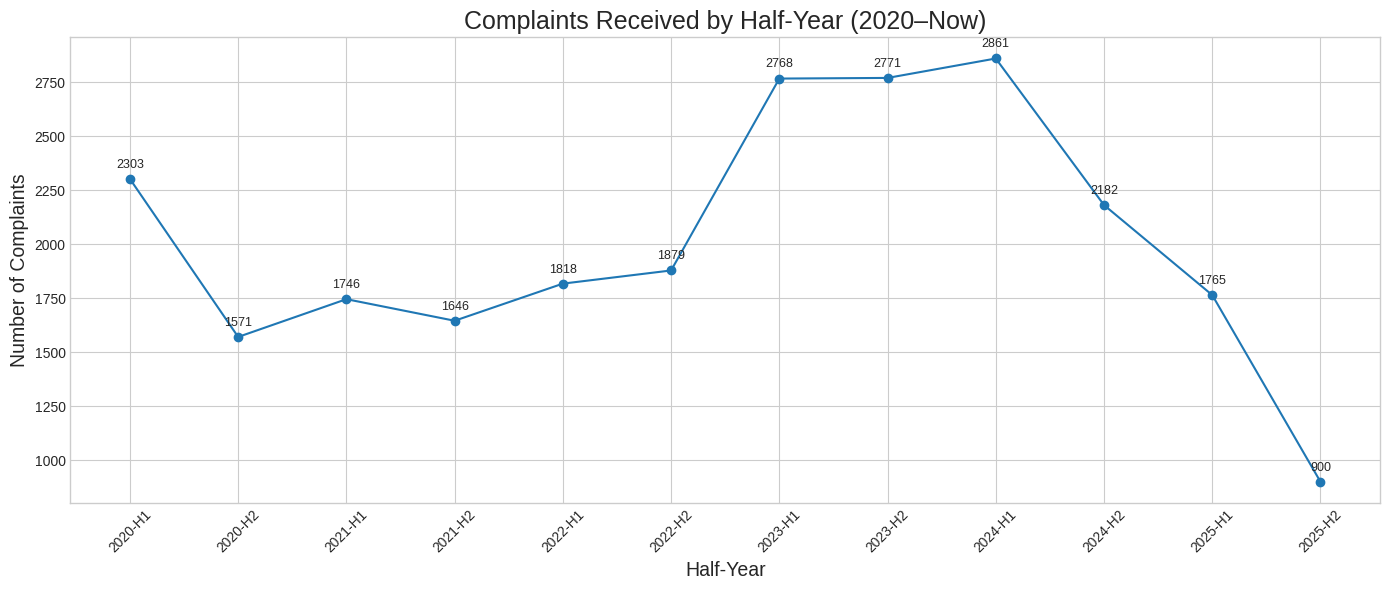

In [ ]:
df_complaints_2020 = df_complaints[df_complaints['CCRB Received Date'] >= "2020-01-01"].copy()


df_complaints_2020['year'] = df_complaints_2020['CCRB Received Date'].dt.year
df_complaints_2020['quarter'] = df_complaints_2020['CCRB Received Date'].dt.quarter

# Map quarter → half (H1 / H2)
df_complaints_2020['half'] = df_complaints_2020['quarter'].map(lambda q: 'H1' if q in [1, 2] else 'H2')

# Make label: "2020-H1"
df_complaints_2020['year_half'] = df_complaints_2020['year'].astype(str) + '-' + df_complaints['half']

# Count complaints per quarter
counts_half = df_complaints_2020.groupby('year_half').size()

x_labels = counts_half.index.tolist()
y_values = counts_half.values

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(x_labels, y_values, marker='o')

# annotate point values
for x, y in zip(x_labels, y_values):
    ax.annotate(str(y), (x, y), textcoords="offset points", xytext=(0, 8),
                ha='center', fontsize=9)

# titles and labels
ax.set_title("Complaints Received by Half-Year (2020–Now)", fontsize=18)
ax.set_xlabel("Half-Year", fontsize=14)
ax.set_ylabel("Number of Complaints", fontsize=14)

# ticks
ax.set_xticks(x_labels)
ax.set_xticklabels(x_labels, rotation=45, fontsize=10)

fig.tight_layout()
fig.savefig(output_figure_folder / "3_Complaints_by_HalfYear.png")
